## Notebook for making figures 

In [1]:
from pathlib import Path
from datetime import datetime
from time import time

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxa
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as pltcolors
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import geopandas as gpd
from shapely.geometry import MultiPoint, Polygon
from rasterio.plot import show as rioshow
# import contextily as ctx

from uavsar_pytools.convert.tiff_conversion import read_annotation
from uavsar_pytools.georeference import geolocate_uavsar

import sys
import os

scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from plotting import plot_tifs_grid, plot_coherence_matrix
from coherence import calc_coherence_unweighted, calc_coherence_matrix
from taus import decorrelation_temporal_model

/Users/julo9057/anaconda3/envs/snowex_uavsar_coherence/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/julo9057/anaconda3/envs/snowex_uavsar_coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/julo9057/anaconda3/envs/snowex_uavsar_coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '../data/snowex_lowman/'
slc_dir = data_dir + 'slcs_geocoded/'
coh_dir = data_dir + 'coherences/'
tau_dir = data_dir + 'taus/'
snotel_dir = data_dir + 'snotel/'
qsi_dir = data_dir + 'snex_qsi_lidar/'
dem_dir = data_dir + 'dem_params/'

fig_dir = '../outputs/figures/insar_final_proj/'

In [3]:
# set the default style of the plots to the seaborn style
# print(plt.style.available)
plt.style.use('seaborn-v0_8')

### Background 

- ?

### Methods

- A map showing the UAVSAR flights, the Mores Creek Summit area, the location of the Snotel site
- The Mores Creek DEM with hillshading 
- The Vegetation height of Mores Creek 
- The location of the Snotel site 

In [4]:
# load UAVSAR, DEM, Snotel pt., vegetation height, basemap 

# load one UAVSAR flight
uavsar_fp = slc_dir + 'lowman_05208_20002_006_200131_L090VV_01_BU_s2_2x8_geoslc.tif'
uavsar = rxa.open_rasterio(uavsar_fp, masked=True).squeeze()

# load Mores Creek DEM and resample
res = 5  # desired resolution in meters
dem_raw = rxa.open_rasterio(qsi_dir + 'SNEX20_QSI_DEM_0.5M_USIDMC_20210917_20210917.tif')
resampled_dem = dem_raw.rio.reproject(dem_raw.rio.crs, resampling=Resampling.average, resolution=(res, res))
dem = resampled_dem.rio.reproject(uavsar.rio.crs)
dem = dem.squeeze()  # remove band dimension
dem = dem.where(dem != dem.rio.nodata)  # set nodata values to NaN

# Snotel site 
snotel_site = (43.9333, -115.6667)

# load vegetation height data
veg_height = rxa.open_rasterio(qsi_dir + 'SNEX20_QSI_VH_0.5M_USIDMC_20200209_20200209.tif')
resampled_veg = veg_height.rio.reproject(veg_height.rio.crs, resampling=Resampling.average, resolution=(res, res))
veg = resampled_veg.rio.reproject_match(dem)
veg = veg.squeeze()  # remove band dimension
veg = veg.where(veg != veg.rio.nodata)  # set nodata values to NaN

# load basemap
basemap = rxa.open_rasterio("../data/snowex_lowman/basemap.tif")
basemap_reproj = basemap.rio.reproject(uavsar.rio.crs)

In [28]:
# establish points of interest
pilot_n = (43.96025, -115.68628)
pilot_s = (43.96002778, -115.6875)
mcs_snotel = (43.9333, -115.6667)

pilot_n_color = 'navy'
pilot_s_color = 'rebeccapurple'
mcs_snotel_color = 'seagreen'
pilot_n_marker = 'o'
pilot_s_marker = 's'
mcs_snotel_marker = '^'

In [5]:
# print bounds to verify
print(uavsar.rio.bounds())
print(basemap.rio.bounds())

(-115.92393493652344, 43.810691833496094, -115.36363220214844, 44.19214630126953)
(-12914838.517577523, 5420340.768272559, -12836567.0006135, 5498612.2852365775)


In [6]:
# get the outlines of valid data for UAVSAR and DEM
# import matplotlib.pyplot as plt
def valid_data_outline(da):
    arr = da.values
    if arr.ndim == 3:
        arr = arr[0, :, :]  # take first band if multi-band
    # Find valid (non-NaN) pixel indices
    valid = np.argwhere(~np.isnan(arr))
    if valid.shape[0] == 0:
        return None
    # Convert pixel indices to coordinates
    transform = da.rio.transform()
    coords = [transform * (col, row) for row, col in valid]
    # Compute convex hull of valid points
    hull = MultiPoint(coords).convex_hull
    return hull

uavsar_hull = valid_data_outline(uavsar)
dem_hull = valid_data_outline(dem)


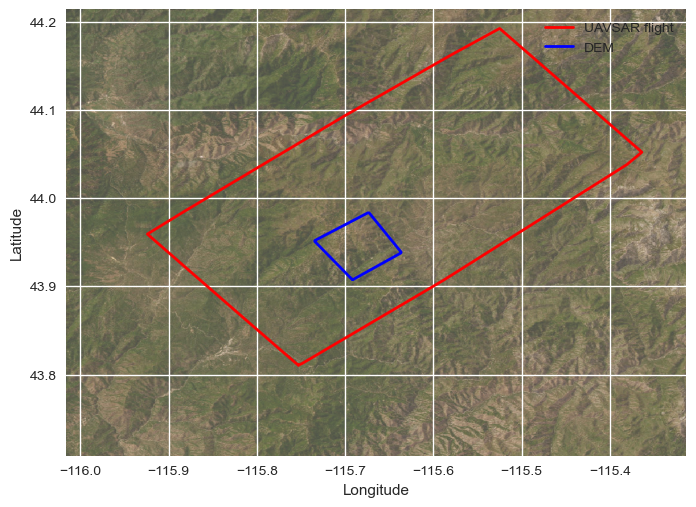

In [7]:
# plot the basemap and outlines. 

# Prepare array for imshow (assumes RGB or single-band)
arr = basemap_reproj.values
if arr.shape[0] >= 3:
    arr = arr[:3, :, :]  # Use first 3 bands for RGB
arr = arr.transpose(1, 2, 0) if arr.ndim == 3 else arr  # (bands, y, x) -> (y, x, bands) or (y, x)
extent = [
    basemap_reproj.x.values.min(), basemap_reproj.x.values.max(),
    basemap_reproj.y.values.min(), basemap_reproj.y.values.max()
 ]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(arr, extent=extent, origin='upper', alpha=0.7)

# Overlay valid data outlines (assumes uavsar_hull and dem_hull already computed)
if uavsar_hull is not None:
    x, y = uavsar_hull.exterior.xy
    ax.plot(x, y, color='red', linewidth=2, label='UAVSAR flight')
if dem_hull is not None:
    x, y = dem_hull.exterior.xy
    ax.plot(x, y, color='blue', linewidth=2, label='DEM')

# boise = ax.plot(43.6150, -116.2023, marker='^', color='blue', linestyle='None', markersize=10, label='Boise')

# Set legend background to white and slightly transparent
legend = ax.legend()
ax.set_aspect('equal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('')
plt.show()

# save figure
fig.savefig(fig_dir + 'data_extents.png', dpi=300, bbox_inches='tight')

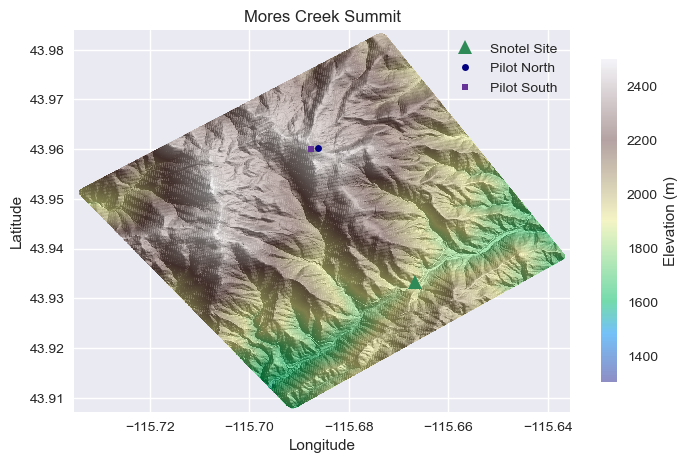

In [30]:
# plot hillshade and DEM 
from matplotlib.colors import LightSource

# create hillshade from DEM
ls = LightSource(azdeg=60, altdeg=60)
hillshade = ls.hillshade(dem.values, vert_exag=1)

# print(hillshade.shape)
dem_shade = dem.copy(data = hillshade)

# plot DEM with hillshading
# plt.style.use('light_background')
fig, ax = plt.subplots(figsize=(8, 6))
# ax = plt.gca() # Get current axes

# Plot hillshade as the base layer
hs = dem_shade.plot(ax=ax, cmap='gray', add_colorbar=False)
elev = dem.plot(ax=ax, cmap='terrain', vmin=1300, vmax=2500, add_colorbar=False, alpha=0.5) 
# add points of interest
ax.plot(mcs_snotel[1], mcs_snotel[0], marker=mcs_snotel_marker, color=mcs_snotel_color, linestyle='None', markersize=10, label='Snotel Site')
ax.plot(pilot_n[1], pilot_n[0], marker=pilot_n_marker, color=pilot_n_color, linestyle='None', markersize=5, label='Pilot North')
ax.plot(pilot_s[1], pilot_s[0], marker=pilot_s_marker, color=pilot_s_color, linestyle='None', markersize=5, label='Pilot South')
ax.legend(frameon=False, loc='upper right')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
# ax.set_facecolor('darkgray')

plt.title("Mores Creek Summit")
plt.colorbar(elev, alpha = 1, label="Elevation (m)", shrink=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# save figure
fig.savefig(fig_dir + 'mores_creek_dem_hillshade.png', dpi=300, bbox_inches='tight')


/var/folders/fj/nxxmv5353nj2t68jvxn1wc4w0000gp/T/ipykernel_18532/2540077514.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='upper right')


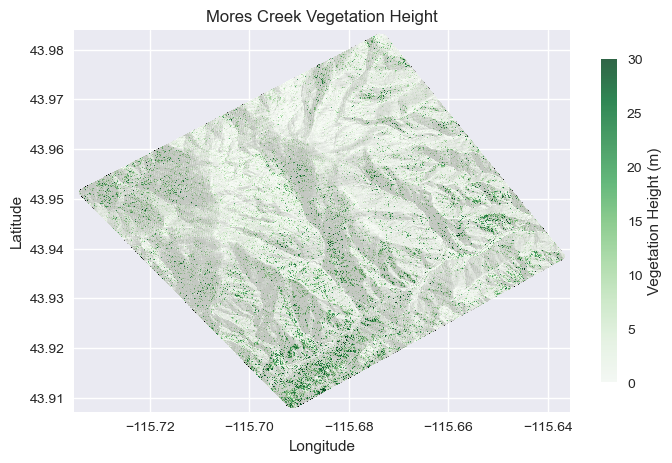

In [9]:
# map vegetation height

fig, ax = plt.subplots(figsize=(8, 6))
hs = dem_shade.plot(ax=ax, cmap='gray', add_colorbar=False)
veg_plot = veg.plot(ax=ax, cmap='Greens', vmin=0, vmax=30, add_colorbar=False, alpha=0.8)
# snotel = ax.plot(snotel_site[1], snotel_site[0], marker='^', color='blue', linestyle='None', markersize=10, label='Snotel Site')
ax.legend(frameon=False, loc='upper right')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)

plt.title("Mores Creek Vegetation Height")
plt.colorbar(veg_plot, alpha = 1, label="Vegetation Height (m)", shrink=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# save figure
fig.savefig(fig_dir + 'mores_creek_veg_height.png', dpi=300, bbox_inches='tight')

In [10]:
# load slope and aspect rasters
slope = rxa.open_rasterio(dem_dir + 'MCS_slope_5m.tif').squeeze()
aspect = rxa.open_rasterio(dem_dir + 'MCS_aspect_5m.tif').squeeze()

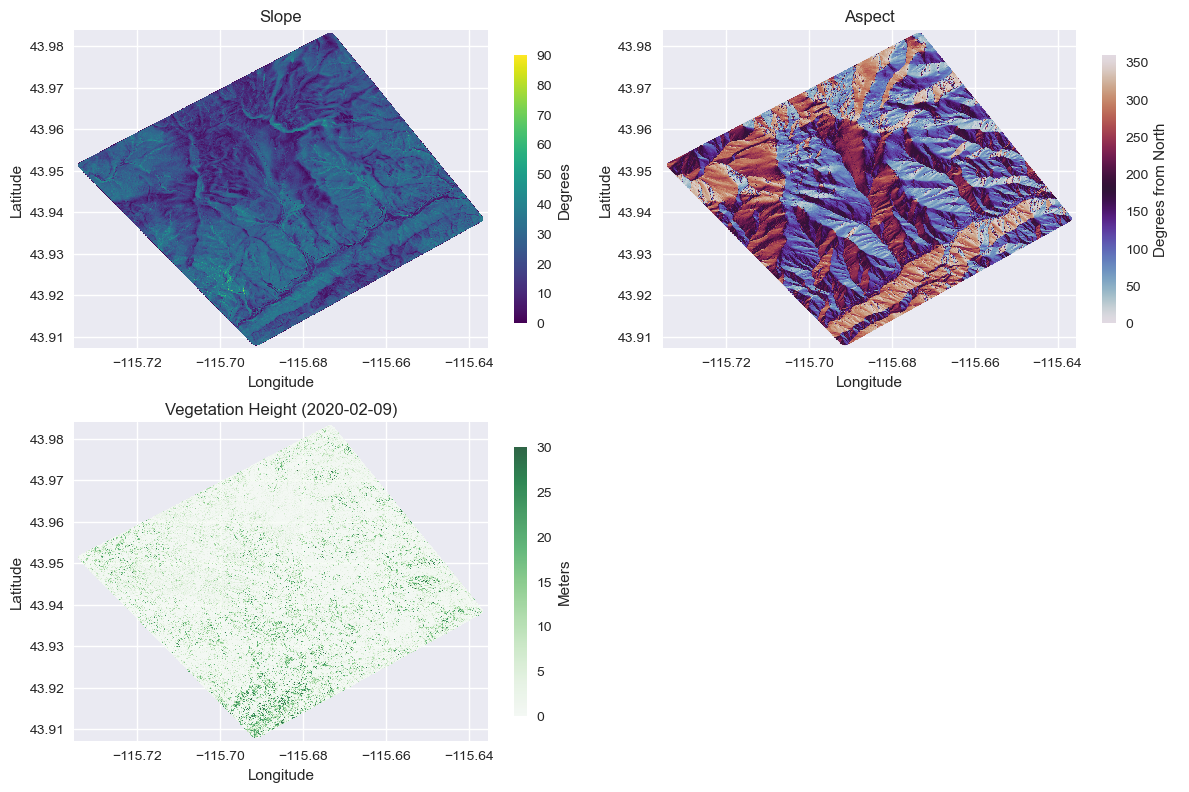

In [11]:
# plot slope and aspect
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
im = slope.plot(ax=axes[0], vmin=0, vmax=90, cmap='viridis', add_colorbar=False)
axes[0].set_title('Slope')
axes[0].set_aspect('equal')
axes[0].grid(True)
axes[0].set_axisbelow(True)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
fig.colorbar(im, ax=axes[0], orientation='vertical', label='Degrees', shrink=0.8)

im2 = aspect.plot(ax=axes[1], cmap='twilight', vmin=0, vmax=360, add_colorbar=False)
axes[1].set_title('Aspect')
axes[1].set_aspect('equal')
axes[1].grid(True)
axes[1].set_axisbelow(True)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
fig.colorbar(im2, ax=axes[1], orientation='vertical', label='Degrees from North', shrink=0.8)

veg_plot = veg.plot(ax=axes[2], cmap='Greens', vmin=0, vmax=30, add_colorbar=False, alpha=0.8)
axes[2].set_title('Vegetation Height (2020-02-09)')
axes[2].set_aspect('equal')
axes[2].grid(True)
axes[2].set_axisbelow(True)
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
fig.colorbar(veg_plot, ax=axes[2], orientation='vertical', label='Meters', shrink=0.8)

axes[3].axis('off')  # turn off unused subplot

plt.tight_layout()
plt.show()

# save figure
fig.savefig(fig_dir + 'parameters.png', dpi=300, bbox_inches='tight')

In [12]:
sd1_orig = rxa.open_rasterio(qsi_dir + 'SNEX20_QSI_SD_0.5M_USIDMC_20200209_20200209.tif')
resampled_sd1 = sd1_orig.rio.reproject(sd1_orig.rio.crs, resampling=Resampling.average, resolution=(res, res))
sd1 = resampled_sd1.rio.reproject(uavsar.rio.crs)
sd1 = sd1.squeeze()  # remove band dimension
sd1 = sd1.where(sd1 != sd1.rio.nodata)  # set nodata values to NaN

sd2_orig = rxa.open_rasterio(qsi_dir + 'SNEX20_QSI_SD_0.5M_USIDMC_20210315_20210315.tif')
resampled_sd2 = sd2_orig.rio.reproject(sd2_orig.rio.crs, resampling=Resampling.average, resolution=(res, res))
sd2 = resampled_sd2.rio.reproject(uavsar.rio.crs)
sd2 = sd2.squeeze()  # remove band dimension
sd2 = sd2.where(sd2 != sd2.rio.nodata)  # set nodata values to NaN

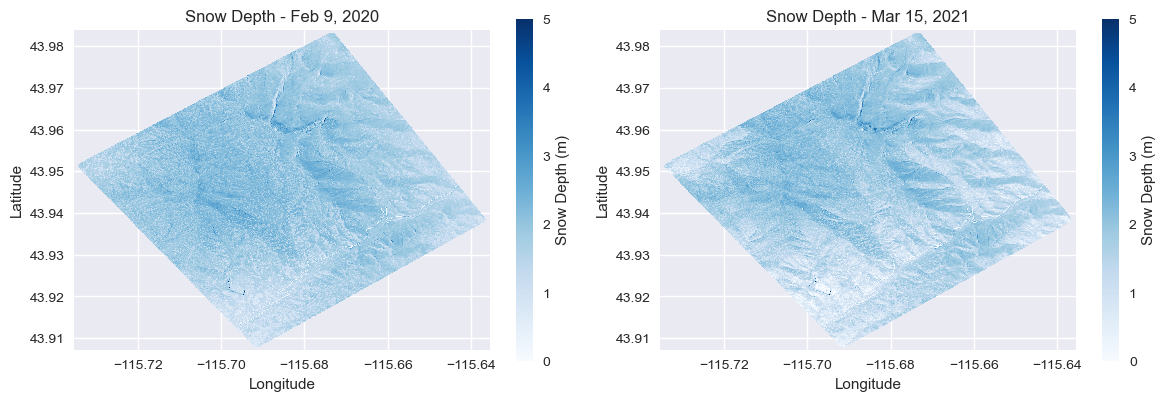

In [13]:
# plot snow depth maps 
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im1 = sd1.plot(ax=axes[0], cmap='Blues', vmin=0, vmax=5, add_colorbar=False)
axes[0].set_title('Snow Depth - Feb 9, 2020')
axes[0].set_aspect('equal')
axes[0].grid(True)
axes[0].set_axisbelow(True)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
cbar1 = fig.colorbar(im1, ax=axes[0], orientation='vertical', label='Snow Depth (m)', shrink=0.6) 
im2 = sd2.plot(ax=axes[1], cmap='Blues', vmin=0, vmax=5, add_colorbar=False)
axes[1].set_title('Snow Depth - Mar 15, 2021')
axes[1].set_aspect('equal')
axes[1].grid(True)
axes[1].set_axisbelow(True)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
cbar2 = fig.colorbar(im2, ax=axes[1], orientation='vertical', label='Snow Depth (m)', shrink=0.6)
plt.tight_layout()
plt.show()

# save figure
fig.savefig(fig_dir + 'snow_depths.png', dpi=300, bbox_inches='tight')

### Temporal coherence model 

- A plot showing what tau and gamma infinity correspond to 
- A histogram of fitted gamma infinities

In [14]:
# load gammas 
tau_and_gamma = rxa.open_rasterio(tau_dir + 'lowman_05208_tau_gamma_fitted.tif')
gamma = tau_and_gamma[1] # gamma is band 2

# plot gammas
# fig, ax = plt.subplots(figsize=(8, 6))
# gamma_plot = gamma.plot(ax=ax, cmap='plasma', vmin=0, vmax=0.25, add_colorbar=False)
# ax.set_aspect('equal')
# ax.grid(True)
# ax.set_axisbelow(True)
# plt.title("Fitted Gamma Inf Values")
# plt.colorbar(gamma_plot, alpha = 1, label="Gamma Inf", shrink=0.7)
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()

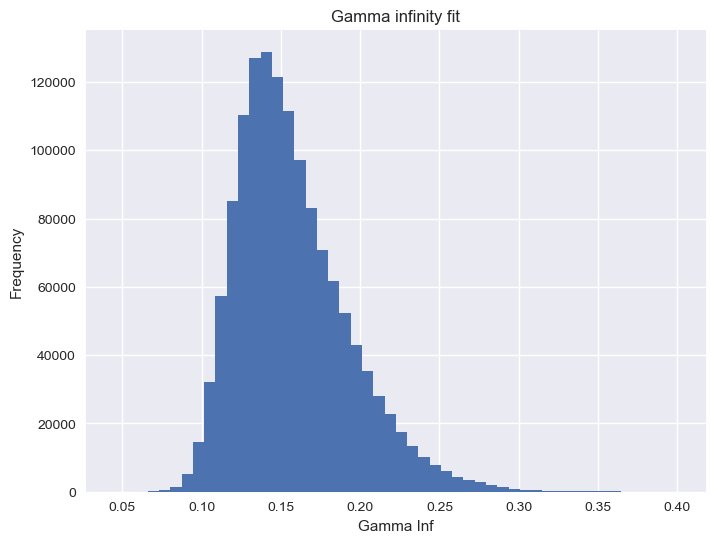

In [15]:
# histogram of gamma infinity
gamma_flat = gamma.values.flatten()
gamma_flat = gamma_flat[~np.isnan(gamma_flat)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(gamma_flat, bins=50)
ax.set_xlabel('Gamma Inf')
ax.set_ylabel('Frequency')
plt.title('Gamma infinity fit')
plt.show()

### Results 

- Map of tau values 
- Principal components analysis using vegetation height, incidence angle

In [ ]:
# load taus 
taus = rxa.open_rasterio(tau_dir + f'lowman_05208_tau_fixed_gamma.tif')

In [18]:
# load coherences and clip them
coherences = []

for coh_file in sorted(list(Path(coh_dir).glob(f'*05208*coherence*.tif'))) :
    # print(f"Loading {coh_tif}...")
    coh_xarr = rxa.open_rasterio(coh_file)[0]
    clipped = coh_xarr.rio.reproject_match(dem, 
                                           nodata = np.nan,
                                           resampling = Resampling.average)
    clipped = clipped.where(~np.isnan(dem))
    coherences.append(clipped)

time_dif = np.loadtxt('../data/snowex_lowman/lowman_05208_day_intervals.txt', dtype=float)

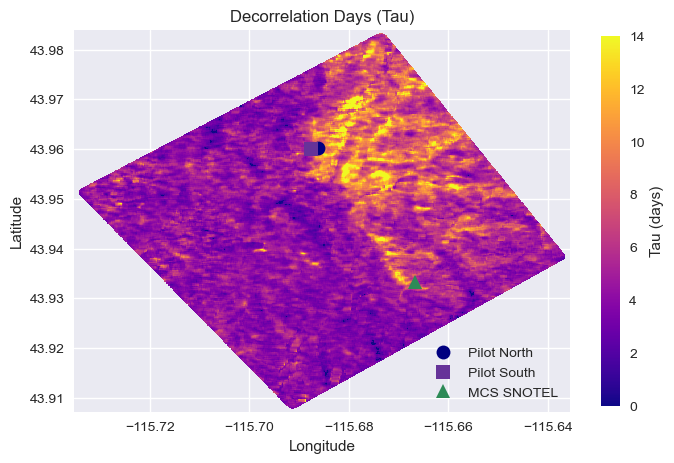

In [31]:
# plot taus 

fig, ax = plt.subplots(figsize=(8, 6))
taus_plot = taus.plot(ax=ax, cmap='plasma', vmin=0, vmax=14, add_colorbar=False)
# add points to map
ax.plot(pilot_n[1], pilot_n[0], markersize=10, marker=pilot_n_marker, color=pilot_n_color, linestyle='None', label='Pilot North')
ax.plot(pilot_s[1], pilot_s[0], markersize=10, marker=pilot_s_marker, color=pilot_s_color, linestyle='None', label='Pilot South')
ax.plot(mcs_snotel[1], mcs_snotel[0], markersize=10, marker=mcs_snotel_marker, color=mcs_snotel_color, linestyle='None', label='MCS SNOTEL')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(loc='lower right')
cbar = fig.colorbar(taus_plot, ax=ax, orientation='vertical', label='Tau (days)', shrink=0.8)
plt.title('Decorrelation Days (Tau)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# save figure
fig.savefig(fig_dir + 'mores_creek_taus.png', dpi=300, bbox_inches='tight')

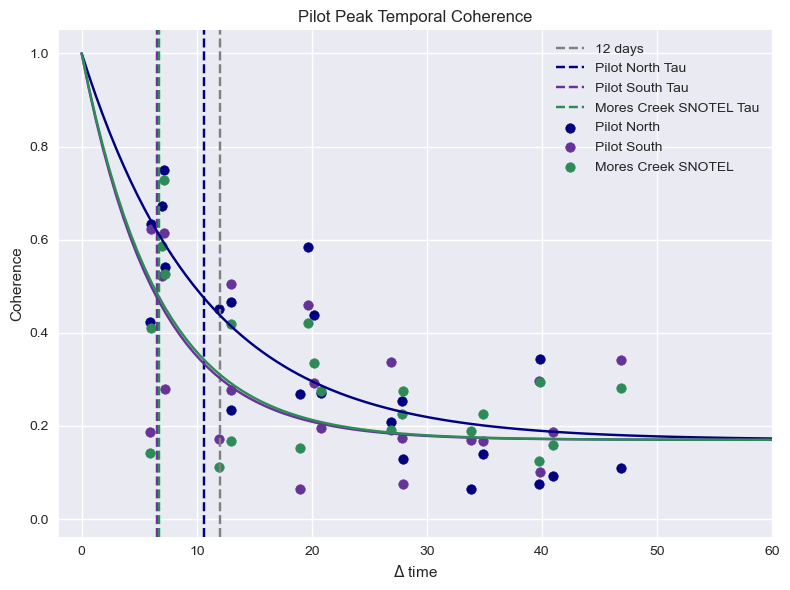

In [20]:
# plot temporal coherence for pilot peak locations and temporal decorrelation model 
tdifs = np.linspace(0, 60, 100)

# plot temporal coherence for pilot peak locations and temporal decorrelation model 
pilot_n_coherences = []
pilot_s_coherences = []
mcs_snotel_coherences = []
for coh in coherences :
    pilot_n_coherences.append(coh.sel(x=pilot_n[1], y=pilot_n[0], method='nearest').values)
    pilot_s_coherences.append(coh.sel(x=pilot_s[1], y=pilot_s[0], method='nearest').values)
    mcs_snotel_coherences.append(coh.sel(x=mcs_snotel[1], y=mcs_snotel[0], method='nearest').values)
# print(pilot_n_coherences)
# print(pilot_s_coherences)
# print(mcs_snotel_coherences)
tau_n = taus.sel(x=pilot_n[1], y=pilot_n[0], method='nearest').values
tau_s = taus.sel(x=pilot_s[1], y=pilot_s[0], method='nearest').values
tau_m = taus.sel(x=mcs_snotel[1], y=mcs_snotel[0], method='nearest').values

fig, ax = plt.subplots(figsize=(8, 6))
ax.axvline(x=12, color='gray', linestyle='--', label='12 days')
ax.axvline(x=tau_n, color=pilot_n_color, linestyle='--', label='Pilot North Tau')
ax.axvline(x=tau_s, color=pilot_s_color, linestyle='--', label='Pilot South Tau')
ax.axvline(x=tau_m, color=mcs_snotel_color, linestyle='--', label='Mores Creek SNOTEL Tau')
ax.scatter(time_dif, pilot_n_coherences, c=pilot_n_color, label="Pilot North")
ax.scatter(time_dif, pilot_s_coherences, c=pilot_s_color, label="Pilot South")
ax.scatter(time_dif, mcs_snotel_coherences, c=mcs_snotel_color, label="Mores Creek SNOTEL")
ax.set_xlabel(r"$\Delta$ time")
ax.set_ylabel("Coherence")
ax.set_xlim(-2, 60)
ax.legend(loc='upper right')
ax.plot(tdifs, [decorrelation_temporal_model(t, 0.17, tau_n) for t in tdifs], c=pilot_n_color, label="Pilot North fit")
ax.plot(tdifs, [decorrelation_temporal_model(t, 0.17, tau_s) for t in tdifs], c=pilot_s_color, label="Pilot South fit")
ax.plot(tdifs, [decorrelation_temporal_model(t, 0.17, tau_m) for t in tdifs], c=mcs_snotel_color, label="Mores Creek SNOTEL fit")
plt.title('Pilot Peak Temporal Coherence')
plt.tight_layout()
plt.show()

In [23]:
# plot the slope, aspect, veg height, elevation, and snow depths for all three points as a histogram 
params = {
    'Slope (deg)': slope,
    'Aspect (deg)': aspect,
    'Vegetation Height (m)': veg,
    'Elevation (m)': dem,
    'Snow Depth Feb 9 (m)': sd1,
    'Snow Depth Mar 15 (m)': sd2
}

# Normalize the parameters
# normalized_params = {}
# for name, data in params.items():
#     min_val = data.min().values
#     max_val = data.max().values
#     normalized_data = (data - min_val) / (max_val - min_val)  
#     normalized_params[name] = normalized_data

# Set the number of parameters and the width of the bars
# num_params = len(normalized_params)
# bar_width = 0.2
# x = np.arange(num_params)  # the label locations

# fig, ax = plt.subplots(figsize=(10, 6))

# # Loop through each parameter and plot the bars
# for i, (param_name, param_data) in enumerate(params.items()):
#     pilot_n_value = param_data.sel(x=pilot_n[1], y=pilot_n[0], method='nearest').values
#     pilot_s_value = param_data.sel(x=pilot_s[1], y=pilot_s[0], method='nearest').values
#     mcs_snotel_value = param_data.sel(x=mcs_snotel[1], y=mcs_snotel[0], method='nearest').values
    
#     # Set the positions for each set of bars
#     ax.bar(x[i] - bar_width, pilot_n_value, width=bar_width, color='blue', label='Pilot North' if i == 0 else "")
#     ax.bar(x[i], pilot_s_value, width=bar_width, color='red', label='Pilot South' if i == 0 else "")
#     ax.bar(x[i] + bar_width, mcs_snotel_value, width=bar_width, color='green', label='Mores Creek SNOTEL' if i == 0 else "")

# ax.set_ylabel('Normalized Values')
# ax.set_title('Normalized Parameter Values at Key Locations')
# ax.set_xticks(x)
# ax.set_xticklabels(normalized_params.keys())
# ax.legend()
# plt.tight_layout()
# plt.show()

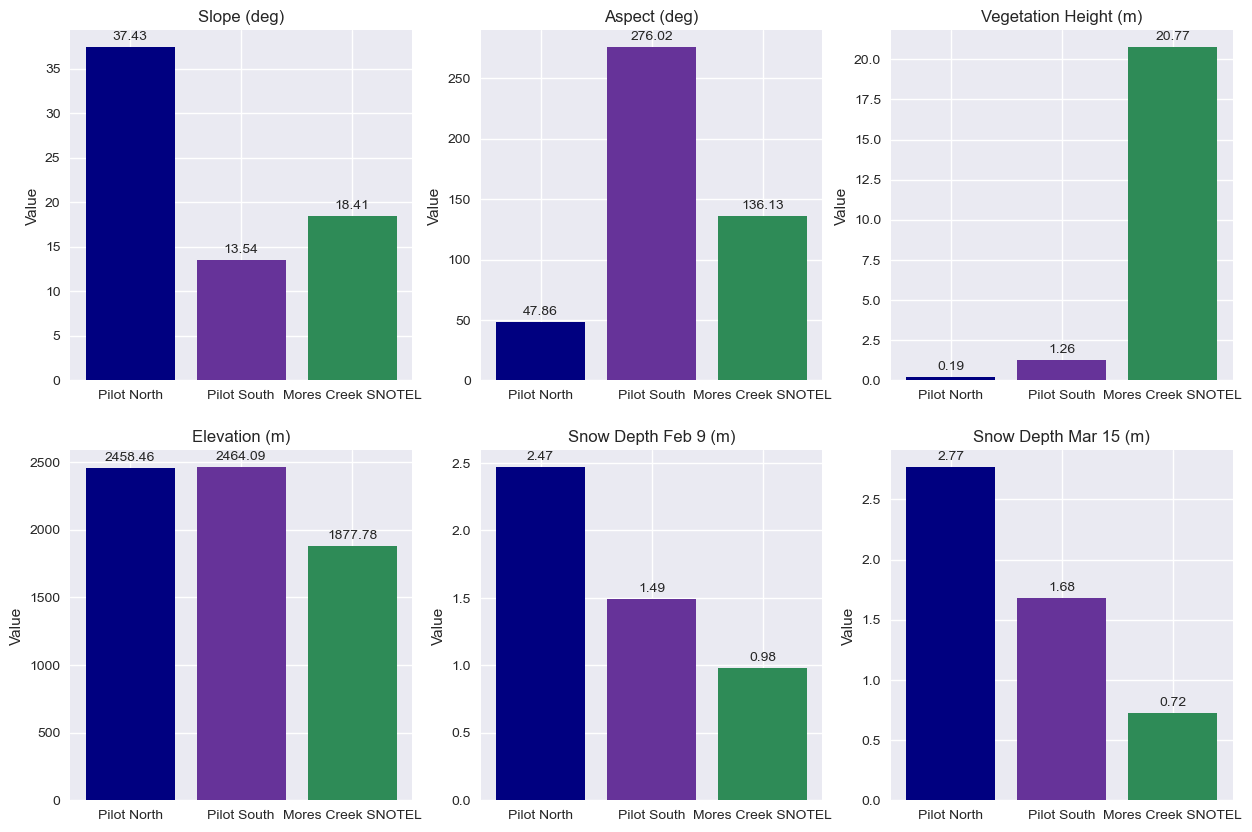

In [22]:
# plot the slope, aspect, veg height, elevation, and snow depths for all three points as separate histograms
params = {
    'Slope (deg)': slope,
    'Aspect (deg)': aspect,
    'Vegetation Height (m)': veg,
    'Elevation (m)': dem,
    'Snow Depth Feb 9 (m)': sd1,
    'Snow Depth Mar 15 (m)': sd2
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  
for i, (param_name, param_data) in enumerate(params.items()):
    ax = axes[i]
    pilot_n_value = param_data.sel(x=pilot_n[1], y=pilot_n[0], method='nearest').values
    pilot_s_value = param_data.sel(x=pilot_s[1], y=pilot_s[0], method='nearest').values
    mcs_snotel_value = param_data.sel(x=mcs_snotel[1], y=mcs_snotel[0], method='nearest').values
    
    bars = ax.bar(['Pilot North', 'Pilot South', 'Mores Creek SNOTEL'], 
                   [pilot_n_value, pilot_s_value, mcs_snotel_value],
                   color=[pilot_n_color, pilot_s_color, mcs_snotel_color])
    
    ax.set_title(param_name)
    ax.set_ylabel('Value')
    
    # Annotate bars with values
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

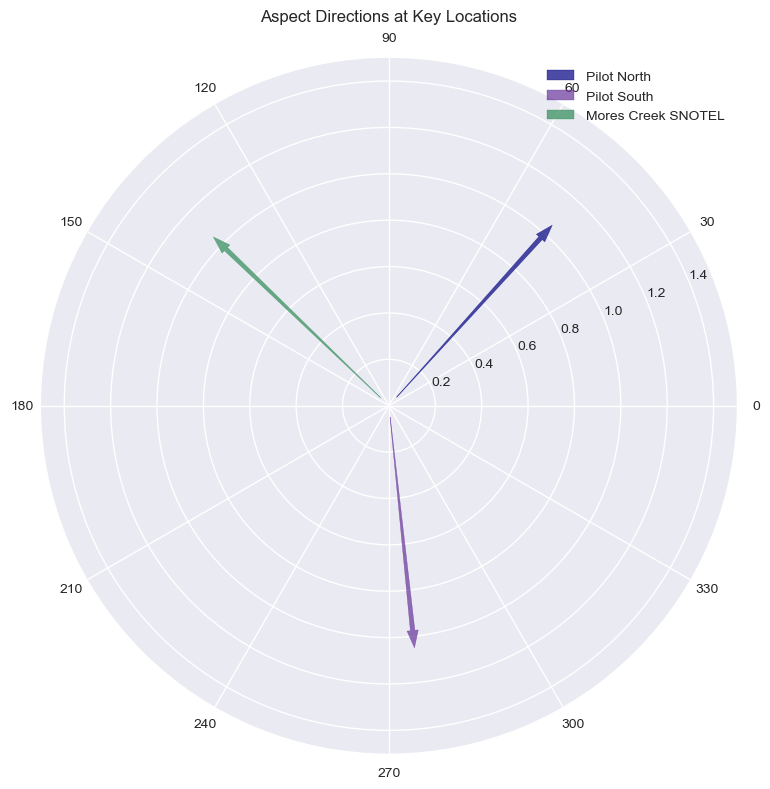

In [27]:
# Extract aspect values for the three points of interest
aspect_values = {
    'Pilot North': aspect.sel(x=pilot_n[1], y=pilot_n[0], method='nearest').values,
    'Pilot South': aspect.sel(x=pilot_s[1], y=pilot_s[0], method='nearest').values,
    'Mores Creek SNOTEL': aspect.sel(x=mcs_snotel[1], y=mcs_snotel[0], method='nearest').values
}

# Create a polar plot for the aspect values
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Convert aspect values from degrees to radians for the polar plot
angles = np.radians(list(aspect_values.values()))

# Create arrows for each point of interest
for i, (location, angle) in enumerate(zip(aspect_values.keys(), angles)):
    ax.arrow(angle, 0.05, 0, 1, alpha=0.7, width=0.02, color=['navy', 'rebeccapurple', 'seagreen'][i],
             label=location, length_includes_head=True, head_width=0.05)

# Set the radial limits
ax.set_ylim(0, 1.5)

# Set title and labels
ax.set_title('Aspect Directions at Key Locations', va='bottom')
ax.set_xticks(np.radians(np.arange(0, 360, 30)))  # Set angular ticks
ax.set_xticklabels(np.arange(0, 360, 30))  # Set angular labels

# Add legend
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()